<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path
from datetime import datetime

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [3]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma[i] * E[i]
        dI[i] =  sigma[i] * E[i] - gamma[i] * I[i]
        dR[i] =  gamma[i] * I[i]
        dC[i] = sigma[i] * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [307]:
np.array([0.3, 0.4, 0.36])/np.array([1/9, 1/6.7, 1/6])

array([2.7 , 2.68, 2.16])

In [323]:
n_regions = 3 
T = 96  #371/7 #96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N = np.array([1100000, 440000, 680000])
## Get the Parameters
beta = np.array([0.3, 0.4, 0.36])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/7)*7     # 1/infectious period per week (Ebola: ~7 days)

sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/6.7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 1, 1])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
C0 = np.array([10, 10, 10])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


In [336]:
np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

array([11499980.,  4499989.,  6799989.])

# Solve the ODEs

In [324]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [325]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [326]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.30821271e+01, 8.38107766e+00, 7.22900586e+00],
       [2.35605344e+01, 1.98258813e+01, 1.52696268e+01],
       [3.98138816e+01, 3.63165946e+01, 2.45213599e+01],
       [6.69911850e+01, 6.58458853e+01, 3.88885444e+01],
       [1.12685275e+02, 1.19326931e+02, 6.16322498e+01],
       [1.89540456e+02, 2.16232339e+02, 9.76728733e+01],
       [3.18806074e+02, 3.91804398e+02, 1.54785780e+02],
       [5.36210508e+02, 7.09835999e+02, 2.45287486e+02],
       [9.01814721e+02, 1.28569559e+03, 3.88686589e+02],
       [1.51654173e+03, 2.32767133e+03, 6.15873855e+02],
       [2.54985696e+03, 4.21065158e+03, 9.75738304e+02],
       [4.28598053e+03, 7.60560267e+03, 1.54559158e+03],
       [7.20063856e+03, 1.37011575e+04, 2.44753615e+03],
       [1.20874065e+04, 2.45637184e+04, 3.87402458e+03],
       [2.02625191e+04, 4.36619644e+04, 6.12741667e+03],
       [3.38879894e+04, 7.64413832e+04, 9.68031279e+03],
       [5.64566206e+04, 1.30362

## Add Noise

In [327]:
from add_noise import Add_noise

observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [328]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_dataset_no_coupling.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,10.000000,0.000000,0,4.499989e+06,...,10.000000,0.000000,0,6.799989e+06,1.000000,10.000000,0.000000,10.000000,0.000000,0
1,2013-12-29,1,1.149996e+07,21.351046,14.032778,9.049349,23.082127,13.082127,8,4.499965e+06,...,18.381078,8.381078,12,6.799969e+06,13.954046,7.884971,9.344034,17.229006,7.229006,9
2,2013-12-30,2,1.149992e+07,36.448061,23.275623,23.367039,46.642662,23.560534,25,4.499930e+06,...,38.206959,19.825881,29,6.799944e+06,23.159020,11.823692,20.674940,32.498633,15.269627,10
3,2013-12-31,3,1.149985e+07,61.371156,39.112605,47.343938,86.456543,39.813882,27,4.499868e+06,...,74.523554,36.316595,24,6.799906e+06,36.790637,18.681443,38.338550,57.019993,24.521360,33
4,2014-01-01,4,1.149974e+07,103.237457,65.785494,87.662234,153.447728,66.991185,67,4.499755e+06,...,140.369439,65.845885,67,6.799846e+06,58.312934,29.601495,66.307042,95.908537,38.888544,29


# Plot the results

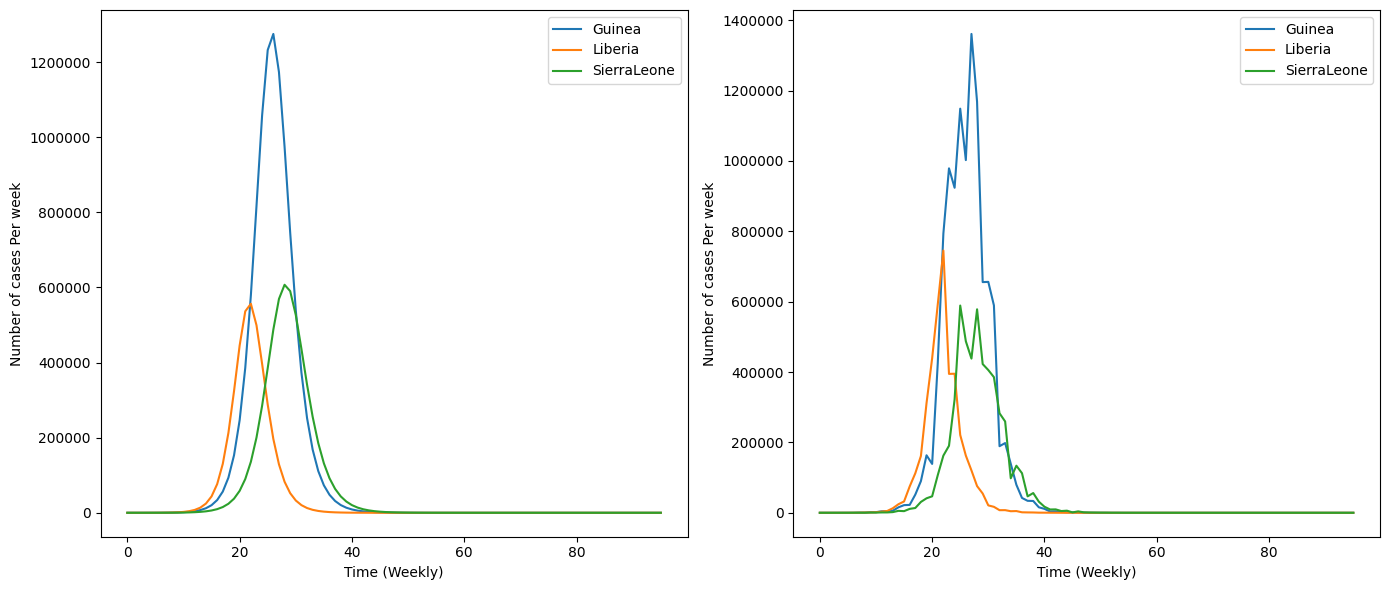

In [329]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')
    ax[0].ticklabel_format(style='plain', axis='y')


    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')
    ax[1].ticklabel_format(style='plain', axis='y')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [330]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

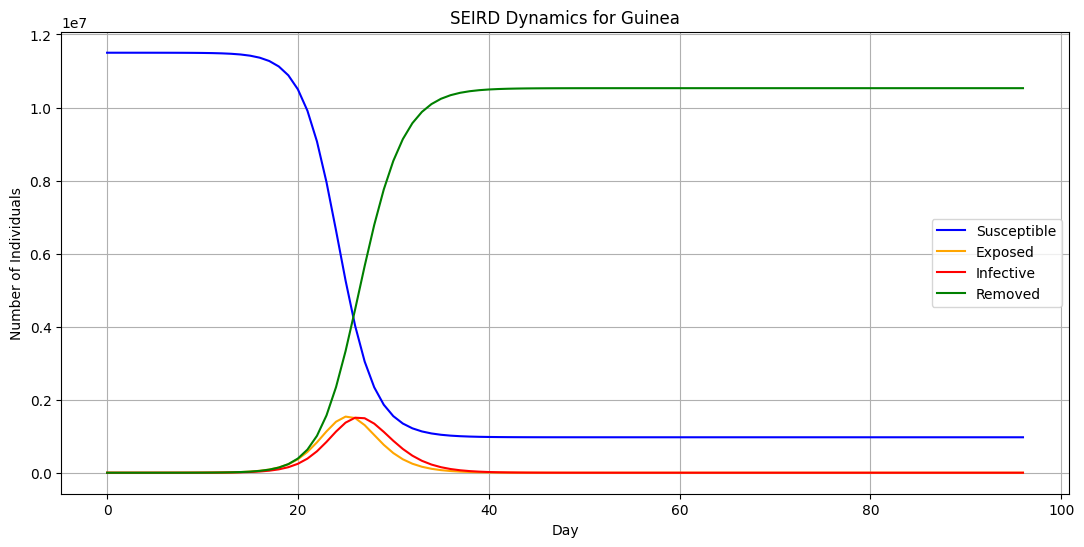

In [331]:
plot_SEIR(raw, 'Guinea')

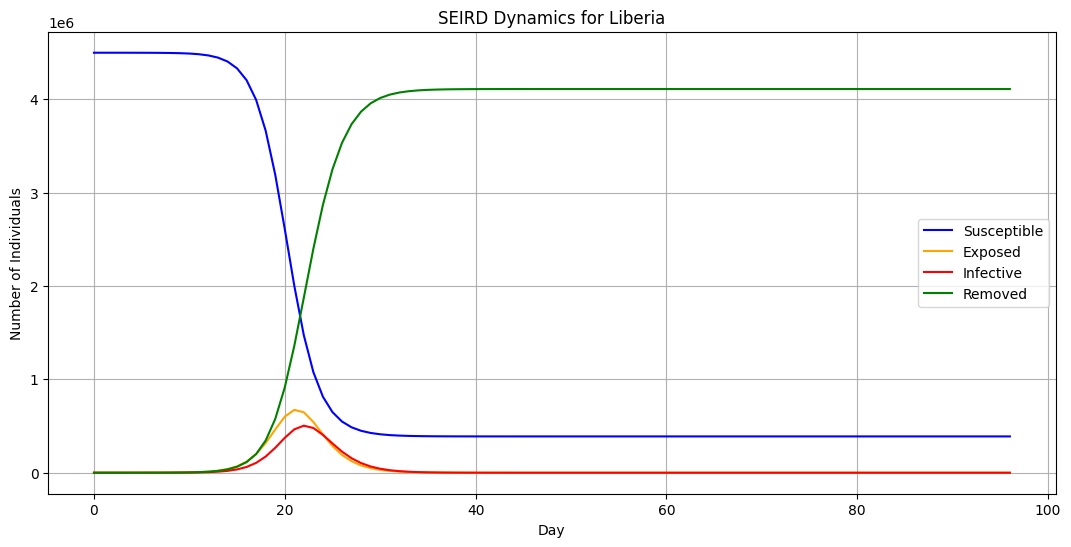

In [332]:
plot_SEIR(raw, 'Liberia')

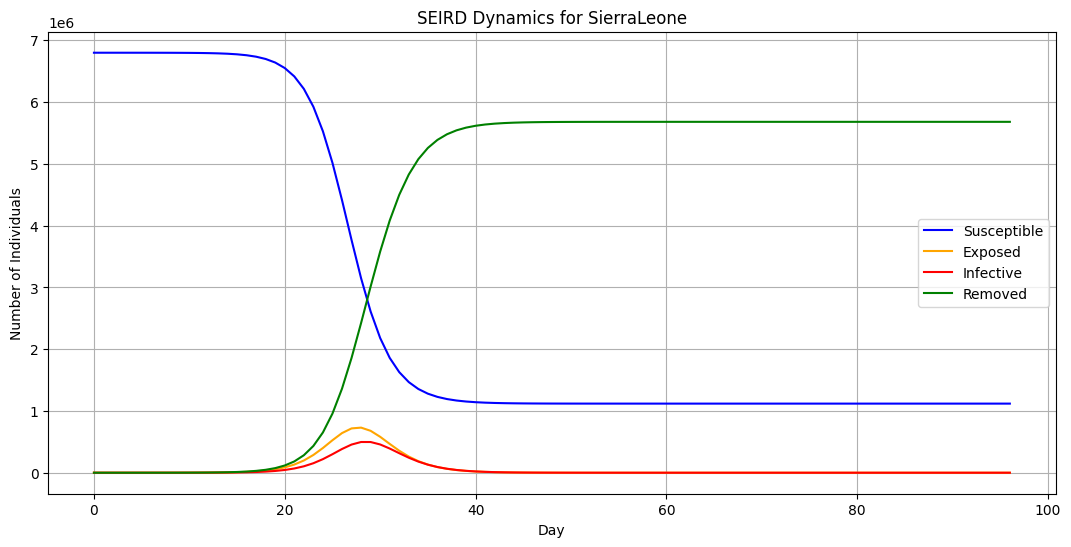

In [333]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [334]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6])

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7 
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/6.7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0 - e0
r0 = [0, 0, 0]
c0 = [10, 10, 10]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [335]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma[0],
    'gamma_value': gamma[0],
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma[1],
    'gamma_value': gamma[1],
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma[2],
    'gamma_value': gamma[2],
    "reporting_rate": reporting_rate
}

In [294]:
seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
# %run fit_single.py
fit1 = seir_incidence_model1.sample(data = seir_data1,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the fit output with a memorable name
output_dir = f'outputs/Guinea_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit1.save_csvfiles(dir=output_dir)
print(f"\nFit for Guinea saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits for Guinea completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 13:55 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 49:42 Sampling completed                       
chain 2 |██████████| 49:42 Sampling completed                       
chain 3 |██████████| 49:42 Sampling completed                       
chain 4 |██████████| 49:42 Sampling completed                       



Fit for Guinea saved to: outputs/Guinea_20250610_220116
Fits for Guinea completed. Check 'output/' directory.


In [42]:
# %run fit_single.py

seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
fit2 = seir_incidence_model2.sample(data = seir_data2,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the fit output with a memorable name
output_dir = f'outputs/Liberia_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit2.save_csvfiles(dir=output_dir)
print(f"\nFit Liberia saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Liberia completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 01:44 Iteration: 1900 / 2000 [ 95%]  (Sampling)






























































chain 1 |██████████| 17:05 Sampling completed                       
chain 2 |██████████| 17:05 Sampling completed                       
chain 3 |██████████| 17:05 Sampling completed                       
chain 4 |██████████| 17:05 Sampling completed                       



Fit Liberia saved to: outputs/Liberia_20250610_171309
Fits Liberia completed. Check 'output/' directory.


In [23]:
# %run fit_single.py
seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
fit3 = seir_incidence_model3.sample(data = seir_data3,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # e.g., 20250607_103939

# Save the fit output with a memorable name
output_dir = f'outputs/Sierraleone_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit3.save_csvfiles(dir=output_dir)
print(f"\nFit Sierra Leone saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Sierra Leone completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 11:06 Iteration: 1900 / 2000 [ 95%]  (Sampling)
































































chain 1 |██████████| 53:33 Sampling completed                       
chain 2 |██████████| 53:33 Sampling completed                       
chain 3 |██████████| 53:33 Sampling completed                       
chain 4 |██████████| 53:33 Sampling completed                       



Fit Sierra Leone saved to: outputs/Sierraleone_20250610_164959
Fits Sierra Leone completed. Check 'output/' directory.


In [357]:
from cmdstanpy import from_csv

# Load Guinea fit
fit1 = from_csv('outputs/Guinea_20250610_150303/simple_seir-*_*.csv')
print("Guinea fit loaded")

# Load Liberia fit
fit2 = from_csv('outputs/Liberia_20250608_104858/simple_seir-*_*.csv')
print("Liberia fit loaded")

# # Load Sierra Leone fit
fit3 = from_csv('outputs/Sierraleone_20250610_164959/simple_seir-*_*.csv')
print("Sierra Leone fit loaded")

Guinea fit loaded
Liberia fit loaded
Sierra Leone fit loaded


In [358]:
print(fit1.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [359]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.872585,0.002288,0.101347,0.097073,0.727969,0.862782,1.052150,1939.90,1822.01,1.00219
beta,2.168350,0.004490,0.164691,0.154991,1.925560,2.149560,2.457410,1548.16,1412.01,1.00292
gamma,0.872409,0.003282,0.116180,0.107352,0.707489,0.860173,1.082860,1329.86,1498.10,1.00290
recovery_time,1.165910,0.004148,0.150488,0.145688,0.923484,1.162560,1.413450,1329.84,1498.10,1.00297
incubation_period,1.161020,0.002967,0.130926,0.131040,0.950428,1.159040,1.373690,1939.95,1822.01,1.00219
R0,2.508810,0.005455,0.213577,0.210025,2.186060,2.491620,2.869470,1591.35,1775.54,1.00343
phi,7.372970,0.035067,1.635120,1.607170,4.986200,7.229870,10.265500,2234.00,2186.21,1.00188
phi_inv,0.142379,0.000683,0.031875,0.030616,0.097413,0.138315,0.200553,2234.00,2186.21,1.00174


In [360]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.030230,0.003472,0.148230,0.137012,0.826168,1.011320,1.309160,1953.87,1871.56,1.00155
beta,2.480060,0.005861,0.231458,0.220685,2.146740,2.455900,2.891150,1636.33,1635.81,1.00061
gamma,0.978627,0.003919,0.160913,0.149793,0.750739,0.957521,1.275680,1775.38,1707.49,1.00051
recovery_time,1.048420,0.003910,0.165815,0.163798,0.783899,1.044360,1.332020,1775.39,1707.49,1.00030
incubation_period,0.989702,0.003078,0.135157,0.136142,0.763852,0.988804,1.210410,1953.89,1871.56,1.00165
R0,2.570110,0.005989,0.265623,0.265452,2.162810,2.555400,3.026830,1948.74,1861.42,1.00126
phi,6.054660,0.029590,1.414740,1.343180,3.978390,5.898460,8.573260,2245.77,2192.80,1.00244
phi_inv,0.174568,0.000910,0.042821,0.038677,0.116641,0.169536,0.251358,2245.75,2192.80,1.00244


In [361]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.953104,0.003238,0.151445,0.141177,0.738453,0.936727,1.228730,2265.74,1843.36,1.00293
beta,2.017740,0.006596,0.239412,0.226045,1.685070,1.983640,2.480820,1409.81,1188.10,1.00163
gamma,0.952479,0.004829,0.172266,0.156508,0.715378,0.926872,1.287740,1408.19,1417.83,1.00089
recovery_time,1.082800,0.005000,0.187370,0.184626,0.776554,1.078900,1.397860,1408.18,1417.83,1.00089
incubation_period,1.074680,0.003466,0.164415,0.160801,0.813844,1.067540,1.354180,2265.73,1843.36,1.00223
R0,2.146410,0.004821,0.200295,0.192493,1.850130,2.123710,2.506180,1798.00,1894.01,1.00075
phi,8.547830,0.035310,1.649310,1.649160,6.091390,8.400600,11.401200,2203.38,2157.44,1.00114
phi_inv,0.121518,0.000534,0.024449,0.023225,0.087710,0.119039,0.164166,2203.38,2157.44,1.00114


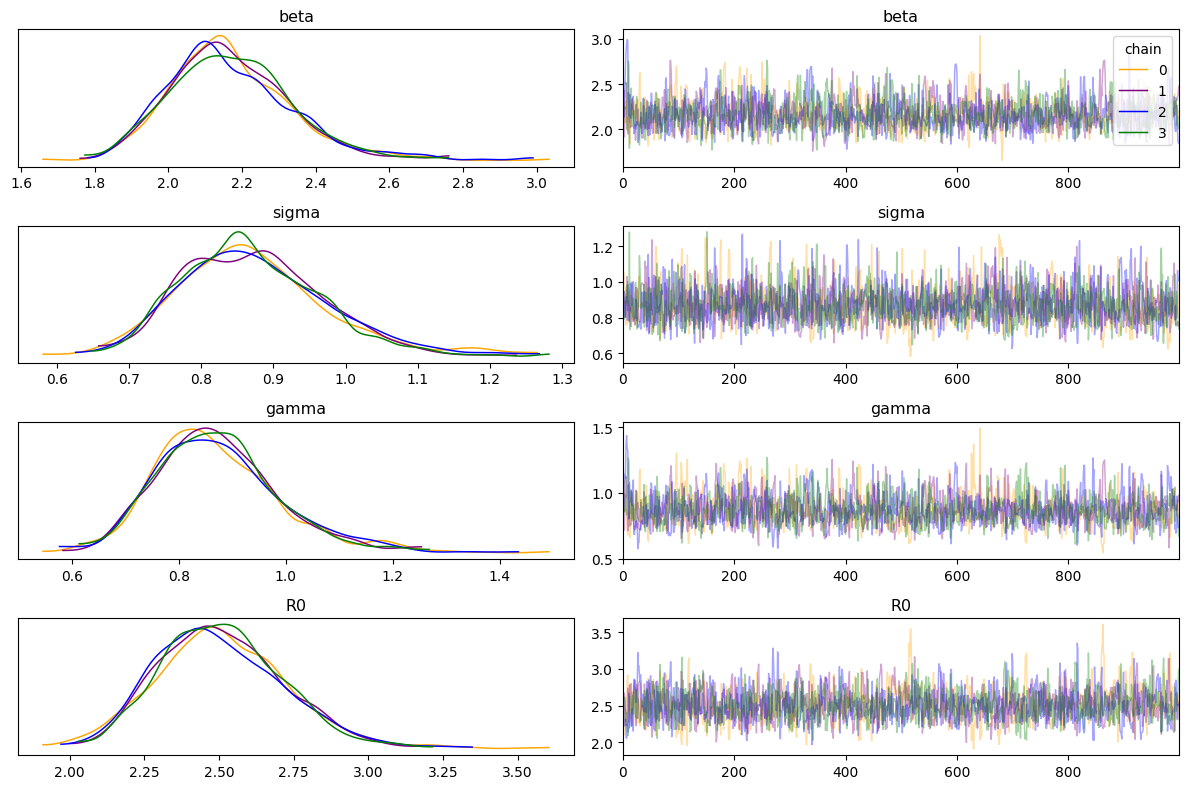

In [362]:
## trace plots
axes = az.plot_trace(fit1, 
              var_names=["beta", "sigma", "gamma", "R0"],
            #   figsize=(12, 8),
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

chain 1 |          | 9:19:07 Status
chain 2 |          | 9:19:07 Status
chain 3 |          | 9:19:07 Status
chain 4 |          | 9:19:07 Status


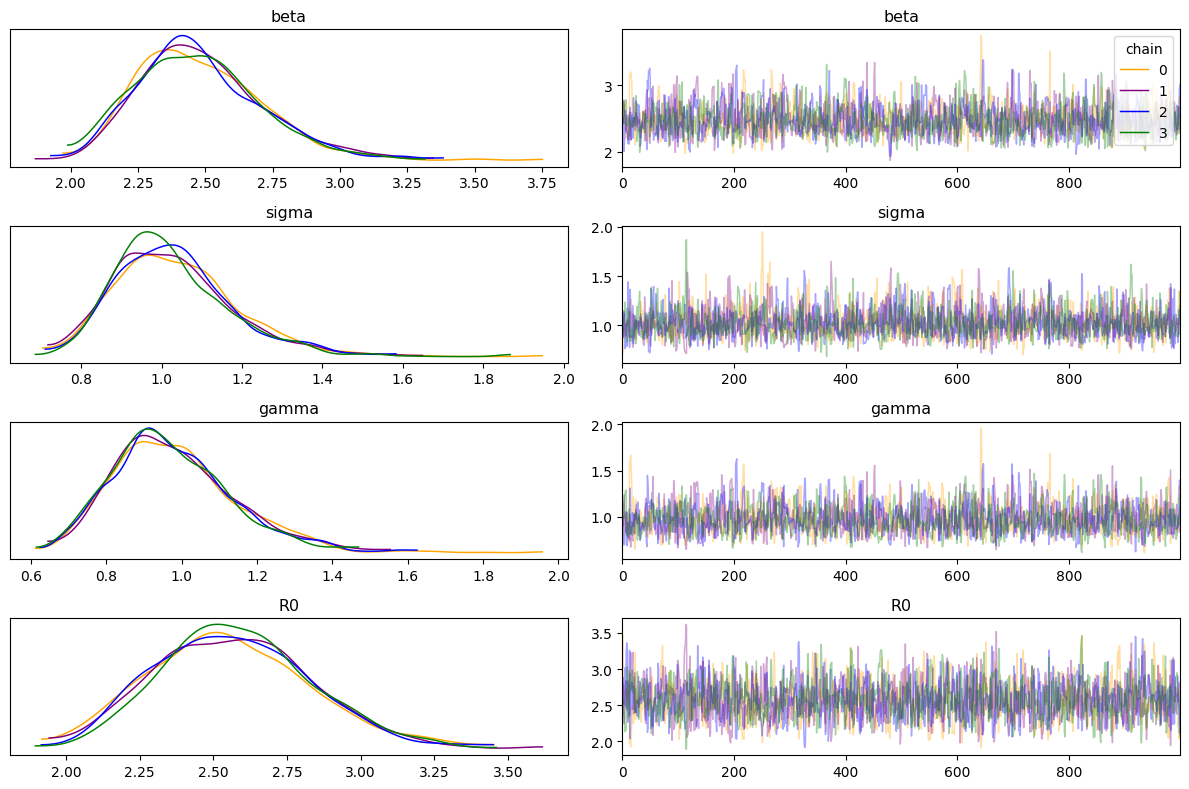

In [363]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

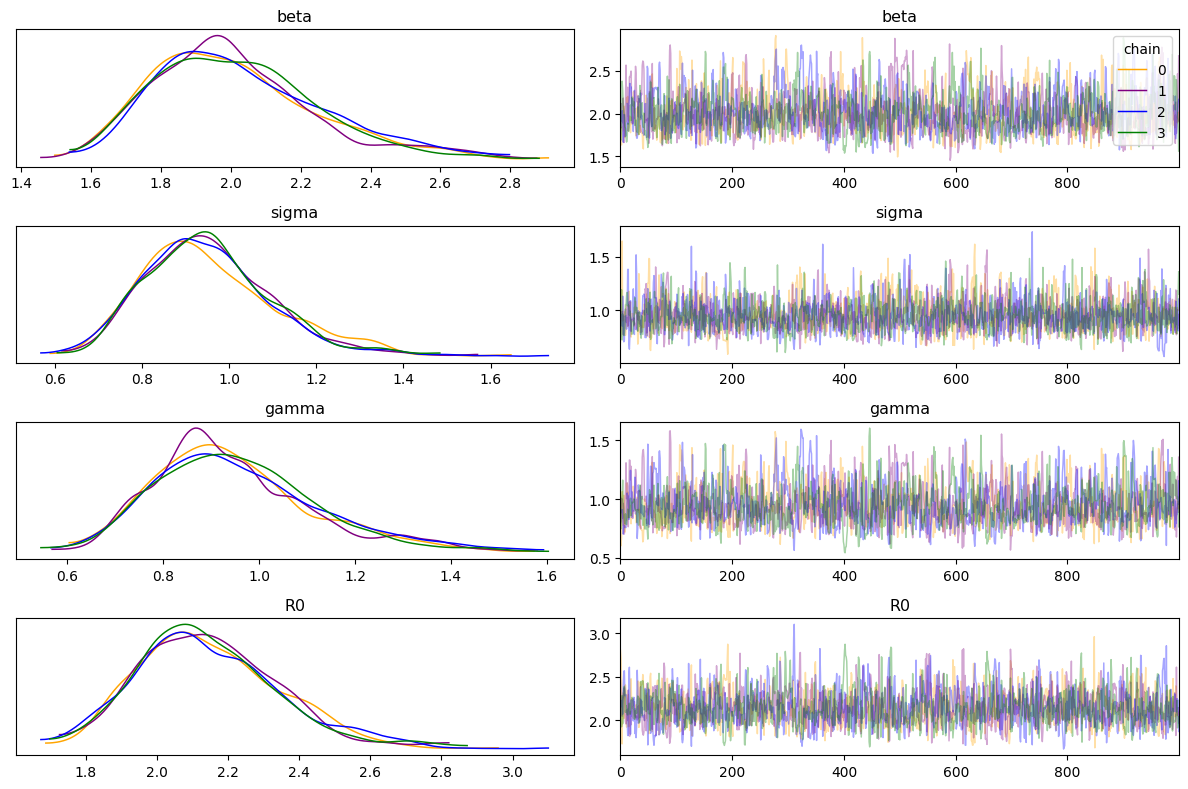

In [364]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
# post_guinea = fit1.draws_pd()
# post_liberia = fit2.draws_pd()
# post_sierra = fit3.draws_pd()

# ## save the posterior samples
# post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
# post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
# post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [134]:
# idata_gp = az.from_cmdstanpy(fit1)
# custom_summary_fns = {
# 	'median': lambda x: np.percentile(x, 50),
# 	'q2.5': lambda x: np.percentile(x, 2.5),
# 	'q97.5': lambda x: np.percentile(x, 97.5),
# }

# mu_sum_gp = az.summary(idata_gp, var_names=['pred_incidence'], stat_funcs=custom_summary_fns, extend=False)

# # mask = mu_sum_gp.index.str.endswith(', 2]') ## get only the infecetious state
# # mu_sum_gp = mu_sum_gp[mask]


# def plot_posterior_summary(year, y, posterior_summary):
# 	fig, ax = plt.subplots(1, 1, figsize=(14, 8))
# 	ax.scatter(year, y, label='Data',)
# 	ax.plot(year, posterior_summary['median'], label='Posterior Median of Incidence', color='red')
# 	ax.fill_between(year, posterior_summary['q2.5'], posterior_summary['q97.5'], color='gray', alpha=0.2, label='95% CI')
# 	ax.set_title('Posterior Median of Incidence vs Data')
# 	ax.set_xlabel('time (weeks)')
# 	ax.set_ylabel('Cases')
# 	ax.legend()
# 	plt.show()


# # Example usage:
# plot_posterior_summary(raw['time'], raw['Guinea_Noise'], mu_sum_gp)

In [370]:
idata_gp1 = az.from_cmdstanpy(fit1)
pred_draws = idata_gp1.posterior['pred_incidence'].stack(sample=("chain", "draw")).values  # shape: (n_samples, T)
# Compute statistics
percentiles = np.percentile(pred_draws, [2.5, 50, 97.5], axis=1)
# percentiles shape: (3, T)
df1 = pd.DataFrame({
    't': np.arange(1, T+1),
    '2.5%': percentiles[0],
    '50%': percentiles[1],
    '97.5%': percentiles[2],
    'incidence': cases1
}).set_index('t')

idata_gp2 = az.from_cmdstanpy(fit2)
pred_draws2 = idata_gp2.posterior['pred_incidence'].stack(sample=("chain", "draw")).values  # shape: (n_samples, T)

percentiles2 = np.percentile(pred_draws2, [2.5, 50, 97.5], axis=1)
# percentiles shape: (3, T)
df2 = pd.DataFrame({
    't': np.arange(1, 53+1),
    '2.5%': percentiles2[0],
    '50%': percentiles2[1],
    '97.5%': percentiles2[2],
    'incidence': cases2[:53]
}).set_index('t')

idata_gp3 = az.from_cmdstanpy(fit3)
pred_draws3 = idata_gp3.posterior['pred_incidence'].stack(sample=("chain", "draw")).values  # shape: (n_samples, T)

percentiles3 = np.percentile(pred_draws3, [2.5, 50, 97.5], axis=1)
# percentiles shape: (3, T)
df3 = pd.DataFrame({
    't': np.arange(1, T+1),
    '2.5%': percentiles3[0],
    '50%': percentiles3[1],
    '97.5%': percentiles3[2],
    'incidence': cases3
}).set_index('t')


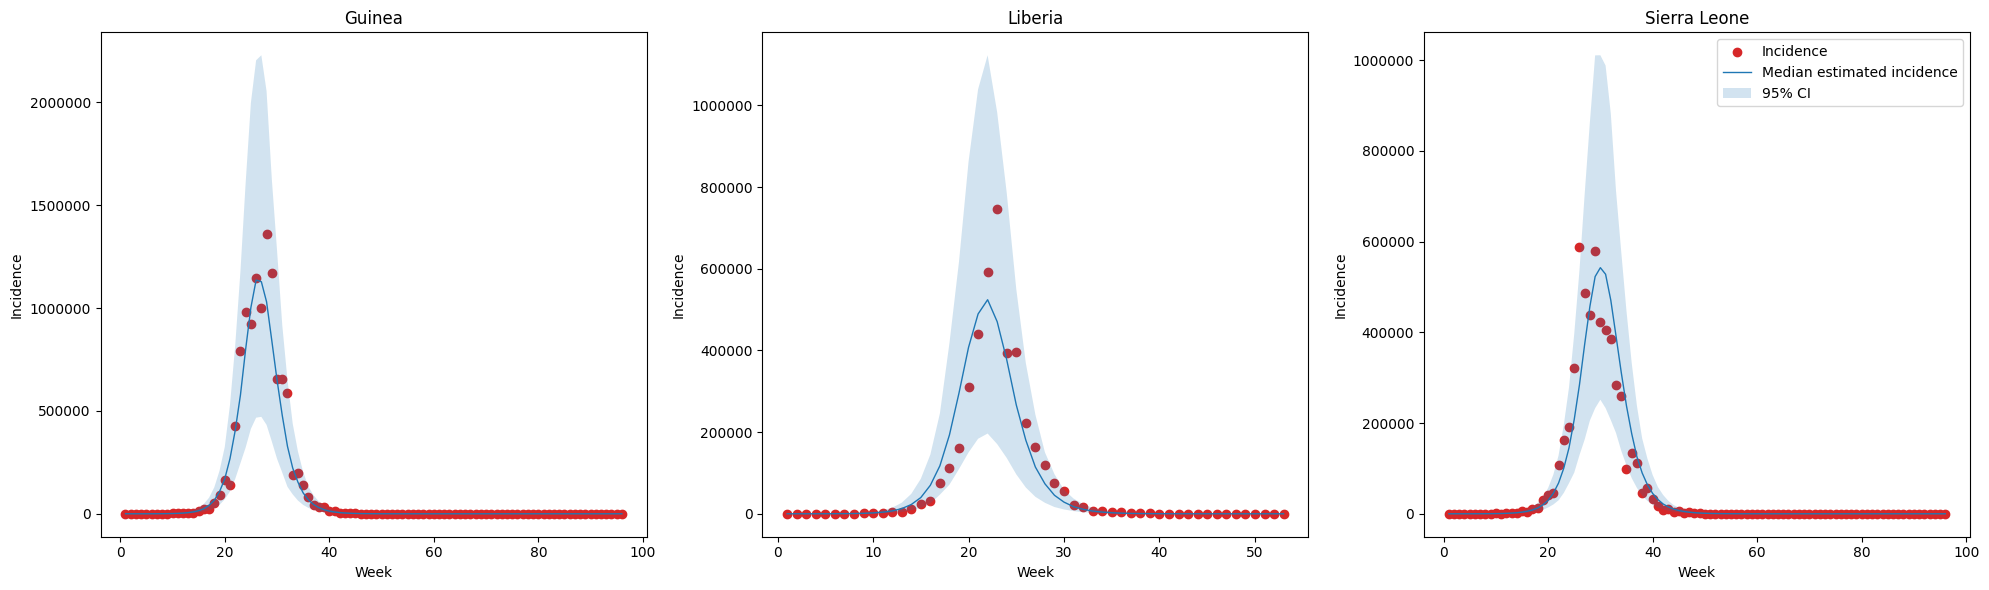

In [371]:
import matplotlib.pyplot as plt

titles = ['Guinea', 'Liberia', 'Sierra Leone']
post_preds = [df1, df2, df3]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for i, (ax, title, df) in enumerate(zip(axes, titles, post_preds)):
    ax.set_title(title)
    ax.set_ylabel('Incidence')
    ax.set_xlabel('Week')
    ax.scatter(df.index, df.incidence, color='tab:red', label="Incidence")
    ax.plot(df['50%'], color='tab:blue', linewidth=1, label="Median estimated incidence")
    ax.fill_between(df.index, df['2.5%'], df['97.5%'], alpha=0.2, label="95% CI")
    ax.ticklabel_format(style='plain', axis='y')
    if i == 2:
        ax.legend()

plt.tight_layout()
plt.savefig('images/poseterior_check_simple.pdf')


In [136]:
# post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
# post_pred2["t"] = range(1, T+1)
# post_pred2["incidence"] = list(cases2)
# post_pred2 = post_pred2.set_index("t")

# plt.figure(figsize=(12, 7))
# plt.grid(True, which='both', color = 'k', alpha = 0.1)
# plt.title(f'Posterior check for Liberia')
# plt.ylabel('Incidence')
# plt.xlabel('Week')
# plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
# plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
# plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# # plt.facecolor('white')
# plt.legend(loc = "upper right")

In [35]:
# post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
# post_pred3["t"] = range(1, T+1)
# post_pred3["incidence"] = list(cases3)
# post_pred3 = post_pred3.set_index("t")

# plt.figure(figsize=(12, 7))
# plt.grid(True, which='both', color = 'k', alpha = 0.1)
# plt.title(f'Posterior check for Sierra Leone')
# plt.ylabel('Incidence')
# plt.xlabel('Week')
# plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
# plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
# plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# # plt.facecolor('white')
# plt.legend(loc = "upper right")

In [372]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7 
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma[0], 'gamma': gamma[0], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec[0],
    'incubation_period': incu[0]}

t2 = {'beta':beta[1],'sigma': sigma[1], 'gamma': gamma[1], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec[1],
    'incubation_period': incu[1]}

t3 = {'beta':beta[2],'sigma': sigma[2], 'gamma': gamma[2], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec[2],
    'incubation_period': incu[2]}

In [381]:
beta/gamma

array([2.7, 2.8, 2.1])

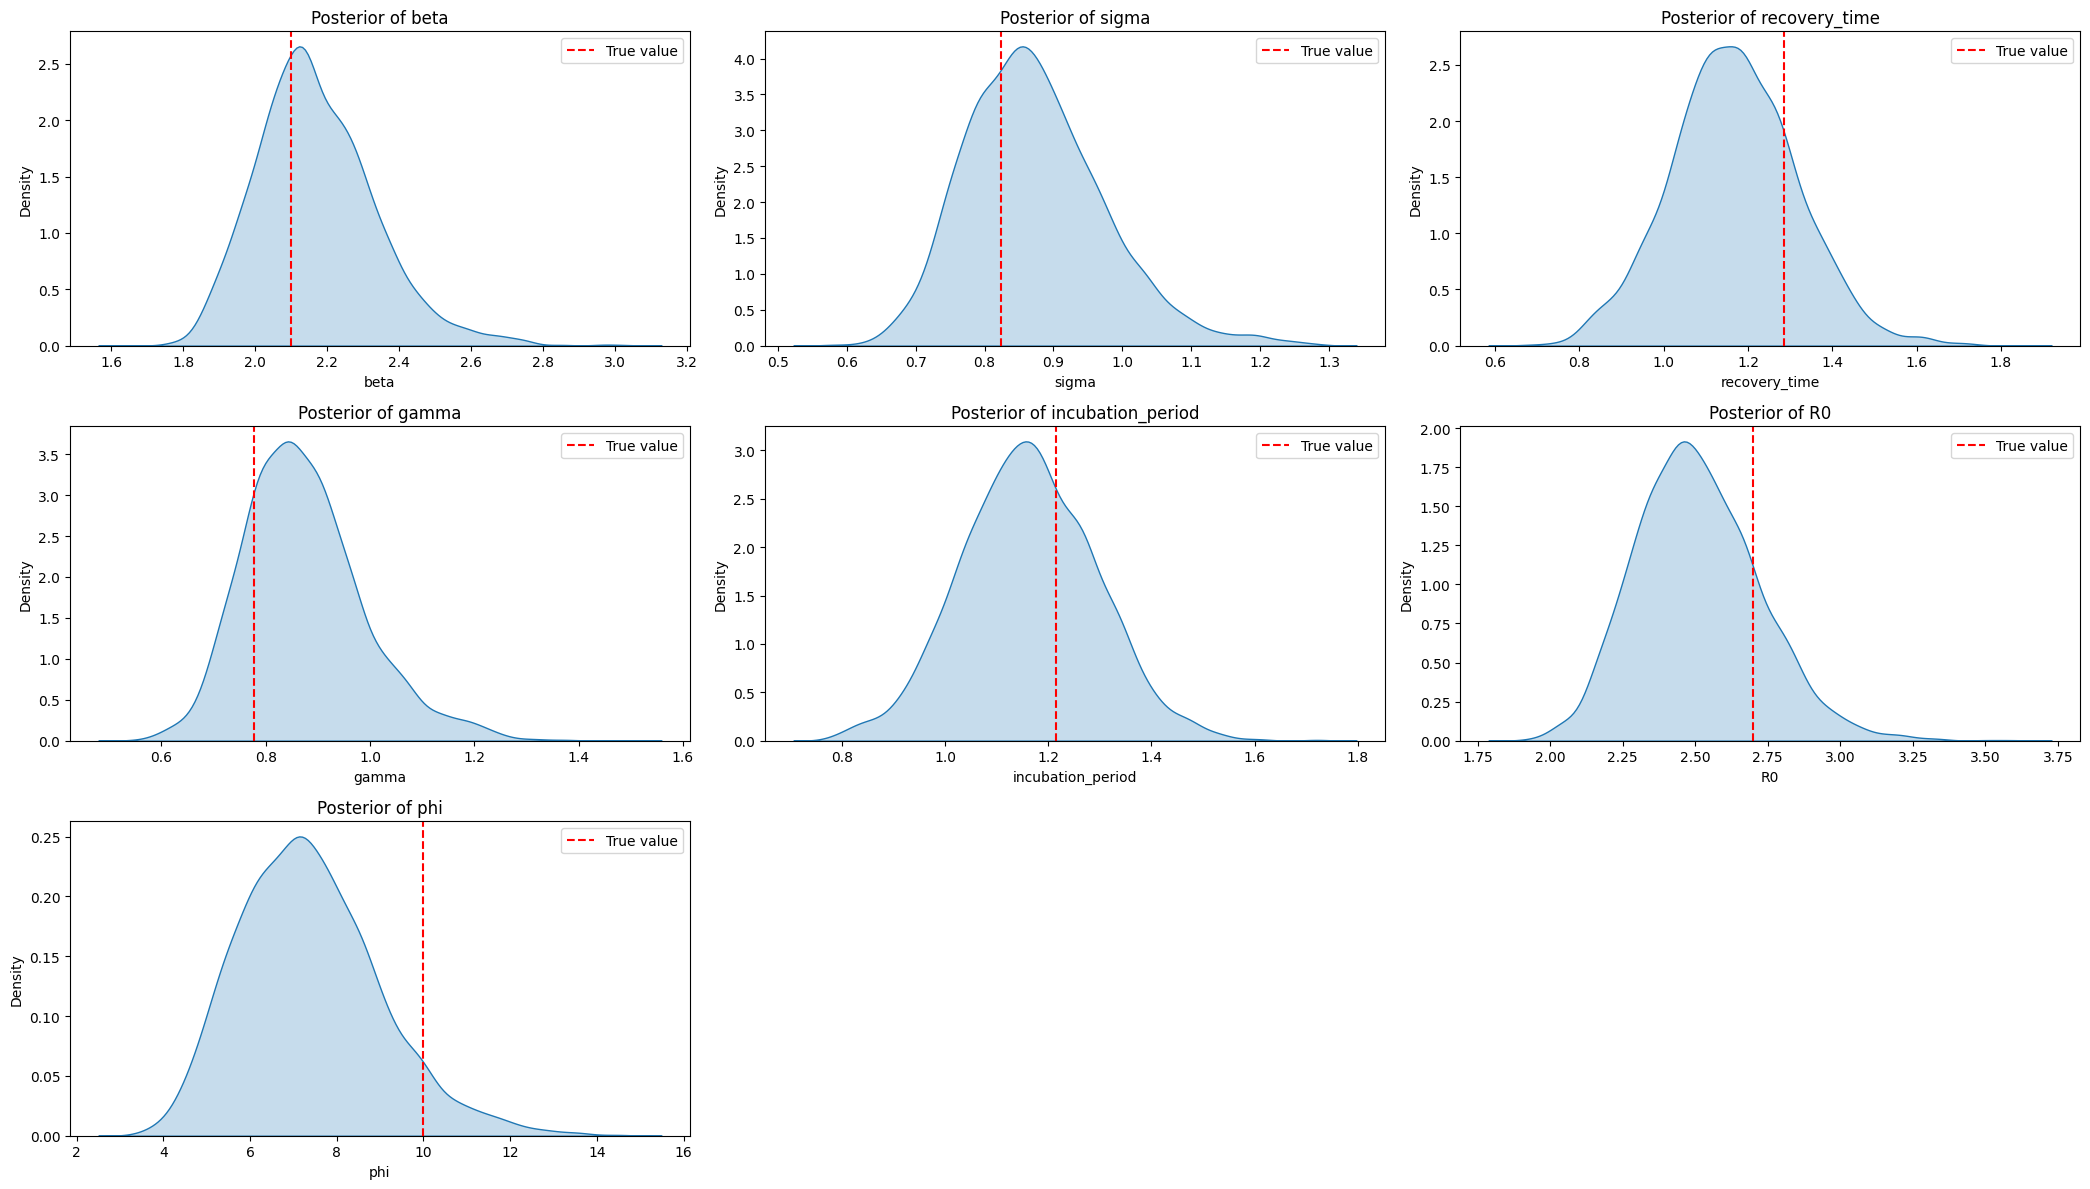

In [373]:
from posterior_plot import plot_posterior_kde_grid

plot_posterior_kde_grid(fit1, parameters1, 3,t1)

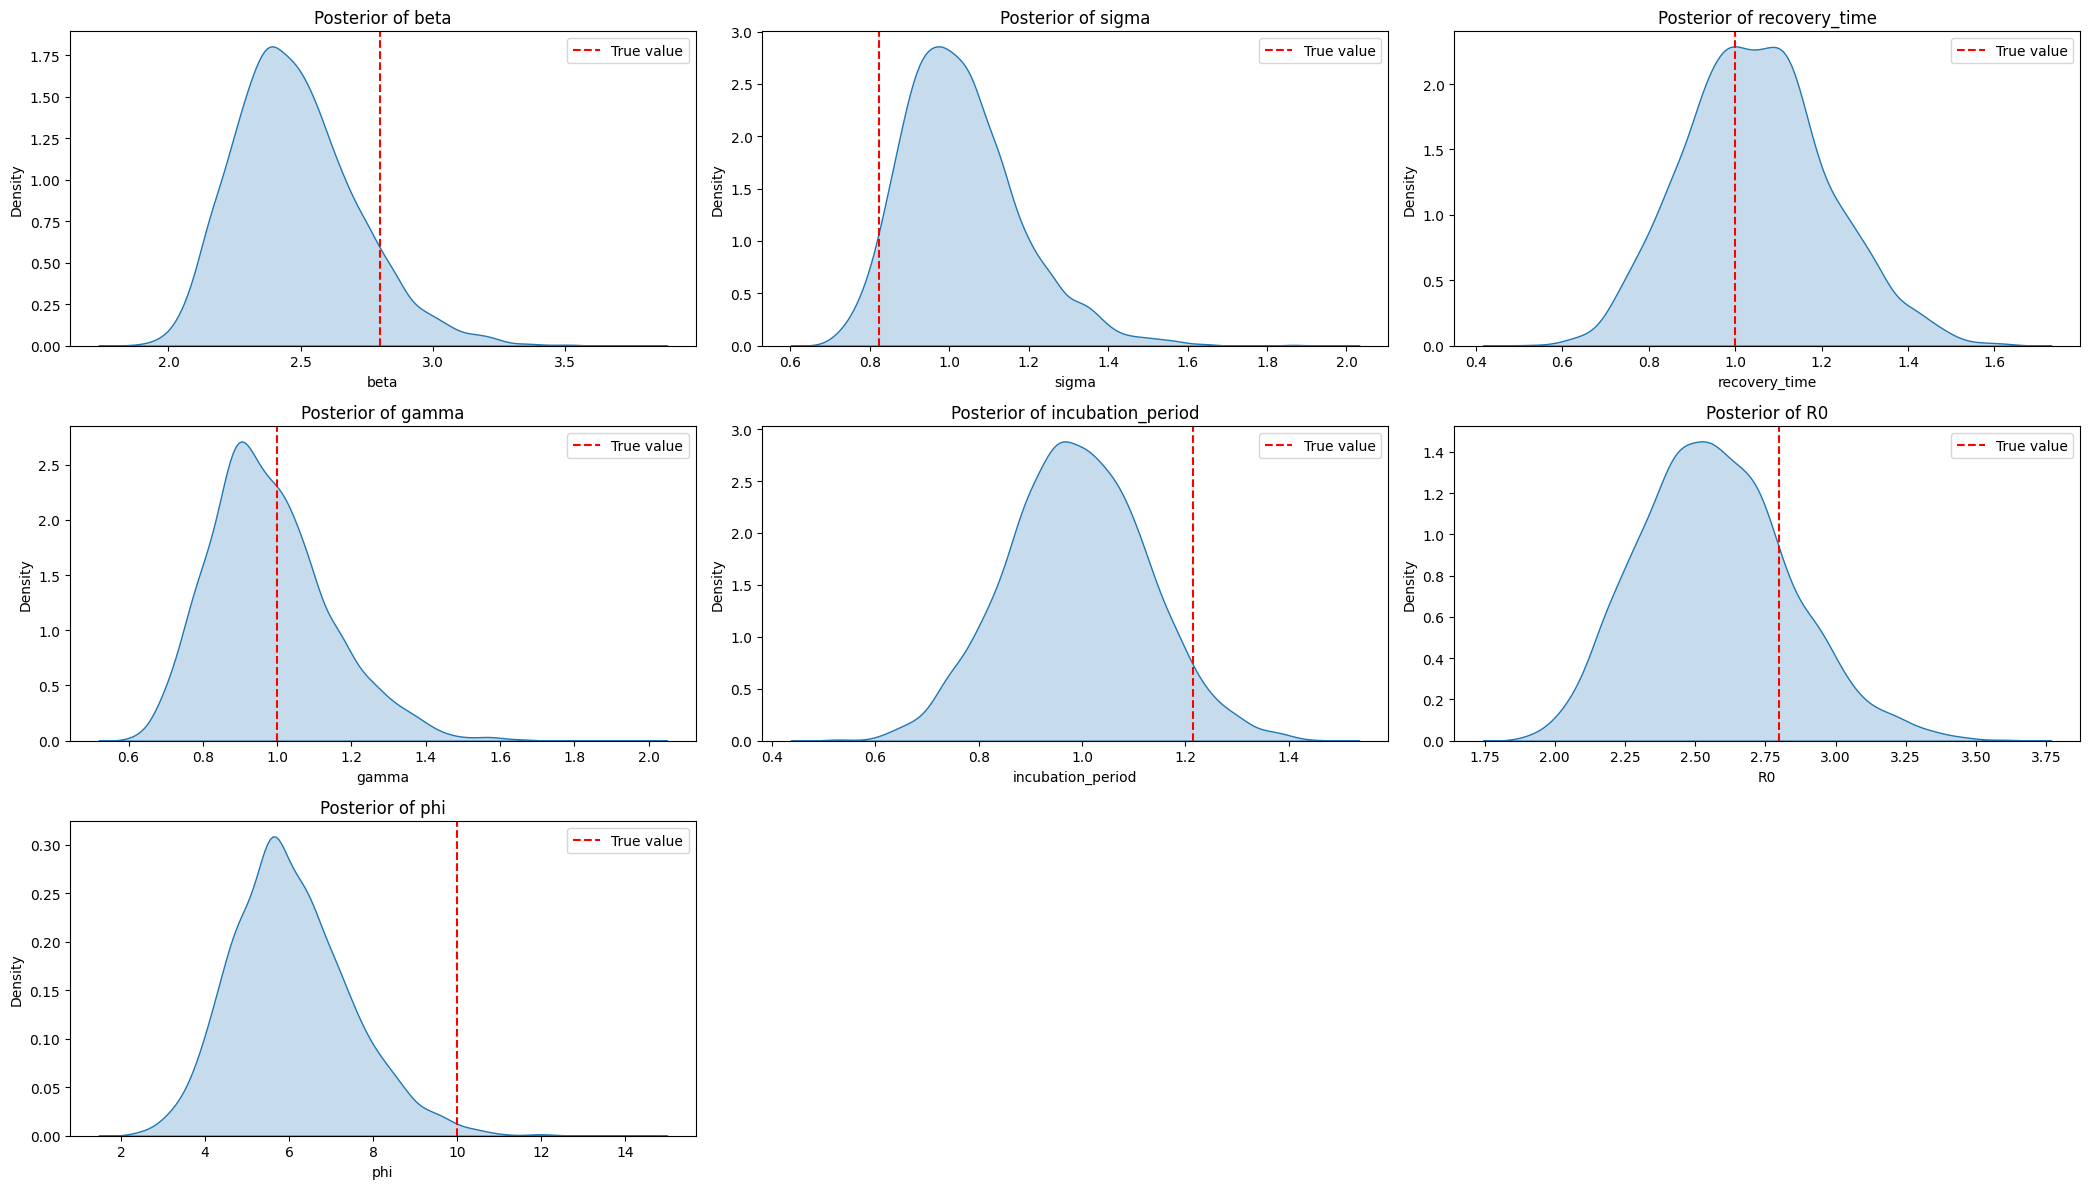

In [374]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2)

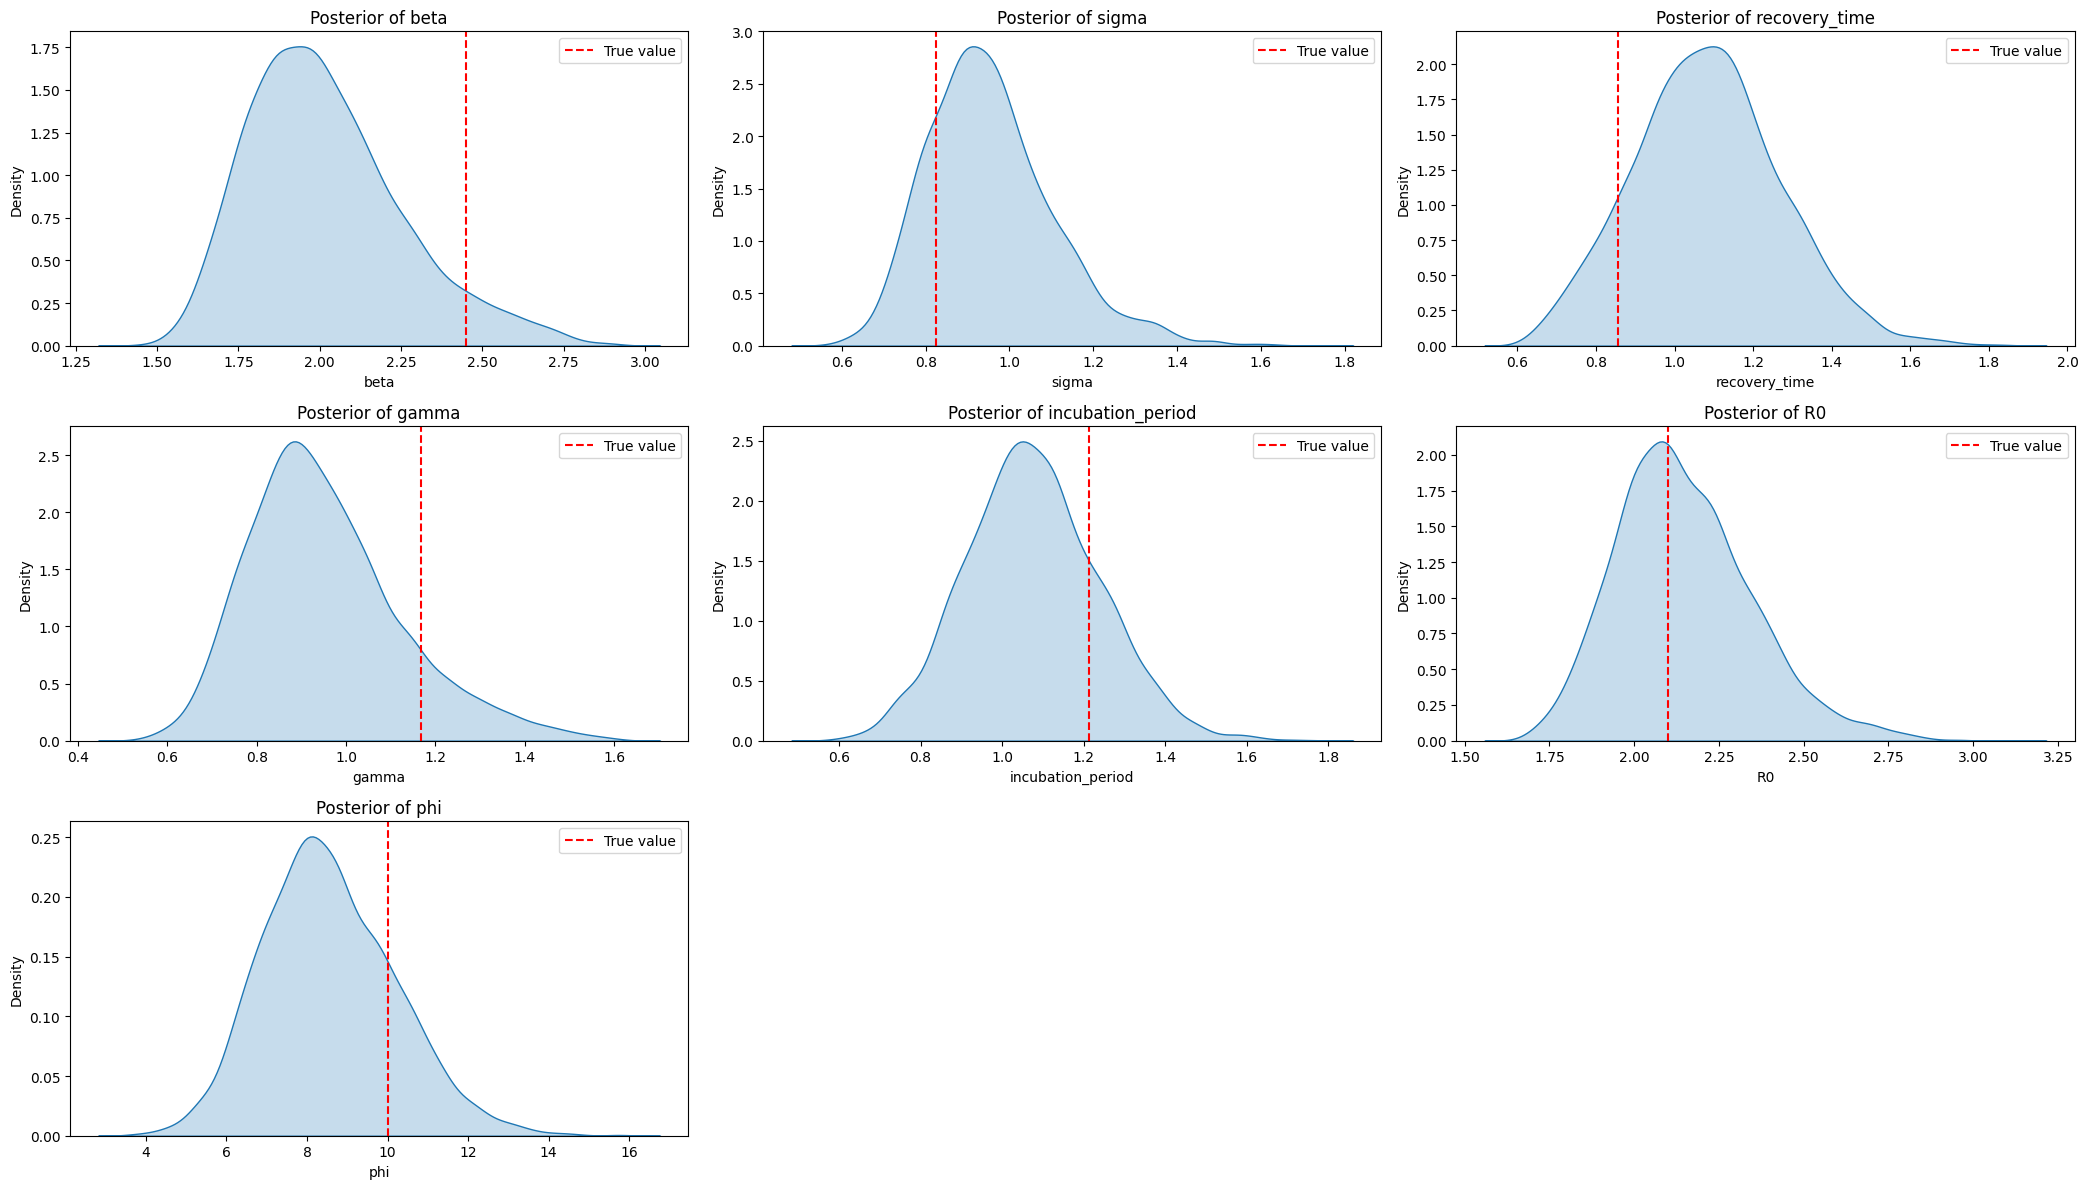

In [375]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3)

## Plot SEIR Compartments

In [376]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 6))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

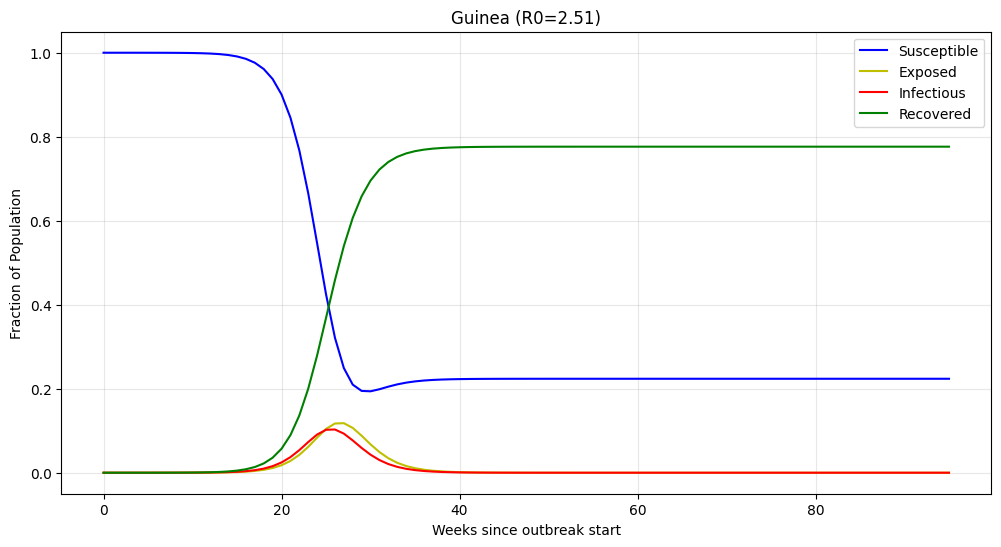

In [377]:
plot_compartment(fit1, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# Plot R0

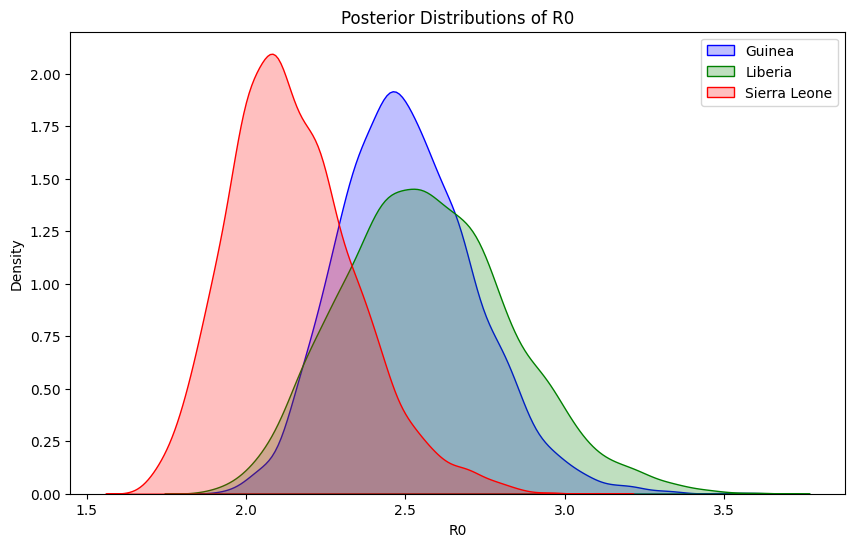

In [378]:
# Extract posterior samples
R0_fit1 = fit1.stan_variable('R0')
R0_fit2 = fit2.stan_variable('R0')
R0_fit3 = fit3.stan_variable('R0')

# Create the plot
plt.figure(figsize=(10, 6))
sns.kdeplot(R0_fit1, label='Guinea', color='blue', fill=True)
sns.kdeplot(R0_fit2, label='Liberia', color='green', fill=True)
sns.kdeplot(R0_fit3, label='Sierra Leone', color='red', fill=True)

# Customize the plot
plt.title('Posterior Distributions of R0')
plt.xlabel('R0')
plt.ylabel('Density')
plt.legend()
plt.grid(False)
plt.show()

/tmp/ipykernel_9482/3482465551.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([R0_fit1, R0_fit2, R0_fit3], labels=['Guinea', 'Liberia', 'Sierra Leone'])


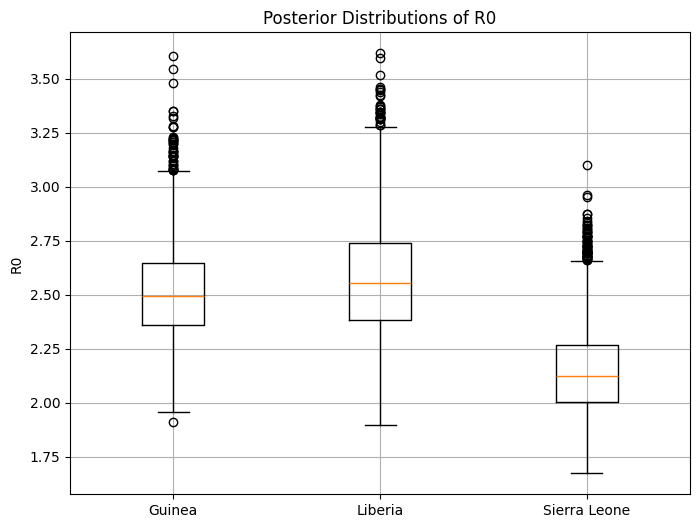

In [379]:
plt.figure(figsize=(8, 6))
plt.boxplot([R0_fit1, R0_fit2, R0_fit3], labels=['Guinea', 'Liberia', 'Sierra Leone'])
plt.title('Posterior Distributions of R0')
plt.ylabel('R0')
plt.grid(True)
plt.show()

# FITTING FOR 3 PATCHES

In [32]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.tail()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
91,0,0,0
92,0,0,0
93,0,0,0
94,0,0,0
95,0,0,0


In [72]:
%run fit_multi.py

Running model fit for All Patches at time 20250610_194517...

Done compiling...Now Sampling!























































































































































































































































































































































































































chain 1 |██████████| 53:48 Sampling completed                       
chain 2 |██████████| 53:48 Sampling completed                       
chain 3 |██████████| 53:48 Sampling completed                       
chain 4 |██████████| 53:47 Sampling completed                       



Fit for all Patches saved to: outputs/all_Patches_20250610_194517
Fits for all Patches completed. Check 'output/' directory.


In [73]:
# Load Guinea fit
fit_multi_model = from_csv('outputs/all_Patches_20250610_194517/mult-*_*.csv')
print("All fit loaded")
print(fit_multi_model.diagnose())

All fit loaded
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [74]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", 
                               "sigma[1]","sigma[2]","sigma[3]",
                                 "gamma[1]","gamma[2]","gamma[3]", "phi"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.942030,0.006908,0.508825,0.481326,1.227710,1.883650,2.88667,5766.04,2944.71,1.00024
beta[2],3.942890,0.013190,0.866855,0.807268,2.710630,3.843840,5.51502,4559.03,3221.61,1.00091
beta[3],3.130330,0.010120,0.730861,0.697519,2.048680,3.047450,4.45891,5305.68,3293.84,1.00111
sigma[1],0.762921,0.003168,0.230683,0.208614,0.458769,0.727437,1.19681,6225.35,2603.29,1.00086
sigma[2],1.027160,0.003885,0.272283,0.256259,0.650919,0.996174,1.52337,4994.11,2879.16,1.00043
sigma[3],0.967521,0.003826,0.265454,0.239943,0.603667,0.929725,1.44894,5703.77,2633.07,1.00081
gamma[1],0.838609,0.003390,0.252004,0.244350,0.495853,0.801686,1.30468,6065.01,2888.07,1.00136
gamma[2],0.898566,0.003479,0.250425,0.231326,0.549858,0.863232,1.34130,5396.64,2980.82,1.00107
gamma[3],1.078090,0.004426,0.303417,0.288492,0.659859,1.042360,1.62105,5105.16,3145.71,1.00051
phi,1.591950,0.013486,0.775299,0.578644,0.742889,1.426550,3.05535,5120.13,2770.38,1.00015


In [67]:

multy_fit_summary.filter(items=("recovery_time[1]", "recovery_time[2]", "recovery_time[3]",
                                "R0[1]","R0[2]", "R0[3]", 
                               "incubation_period[1]","incubation_period[2]","incubation_period[3]"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
recovery_time[1],1.306500,0.005742,0.397659,0.368671,0.772351,1.245900,2.01484,5423.44,2764.96,1.002100
recovery_time[2],1.195900,0.004817,0.347505,0.308527,0.719557,1.142220,1.82710,5742.17,2807.56,1.002470
recovery_time[3],0.995169,0.003598,0.273981,0.250619,0.614562,0.956009,1.50250,6051.38,3015.92,1.000920
R0[1],2.494230,0.013003,0.954379,0.782138,1.335580,2.311300,4.24876,6568.82,3242.71,0.999376
R0[2],4.651300,0.021510,1.501930,1.371700,2.702900,4.405240,7.45997,6097.35,3637.86,1.002670
R0[3],3.080350,0.013013,1.015980,0.938686,1.770080,2.919790,4.94500,6818.98,3364.89,1.000310
incubation_period[1],1.424430,0.005308,0.413521,0.388412,0.857546,1.375900,2.17291,6255.31,2768.73,1.002120
incubation_period[2],1.035890,0.003689,0.264102,0.252797,0.661116,1.007640,1.51432,5322.43,3457.98,1.001440
incubation_period[3],1.112560,0.004193,0.310827,0.293147,0.675556,1.073740,1.67883,5987.50,3358.73,1.001200


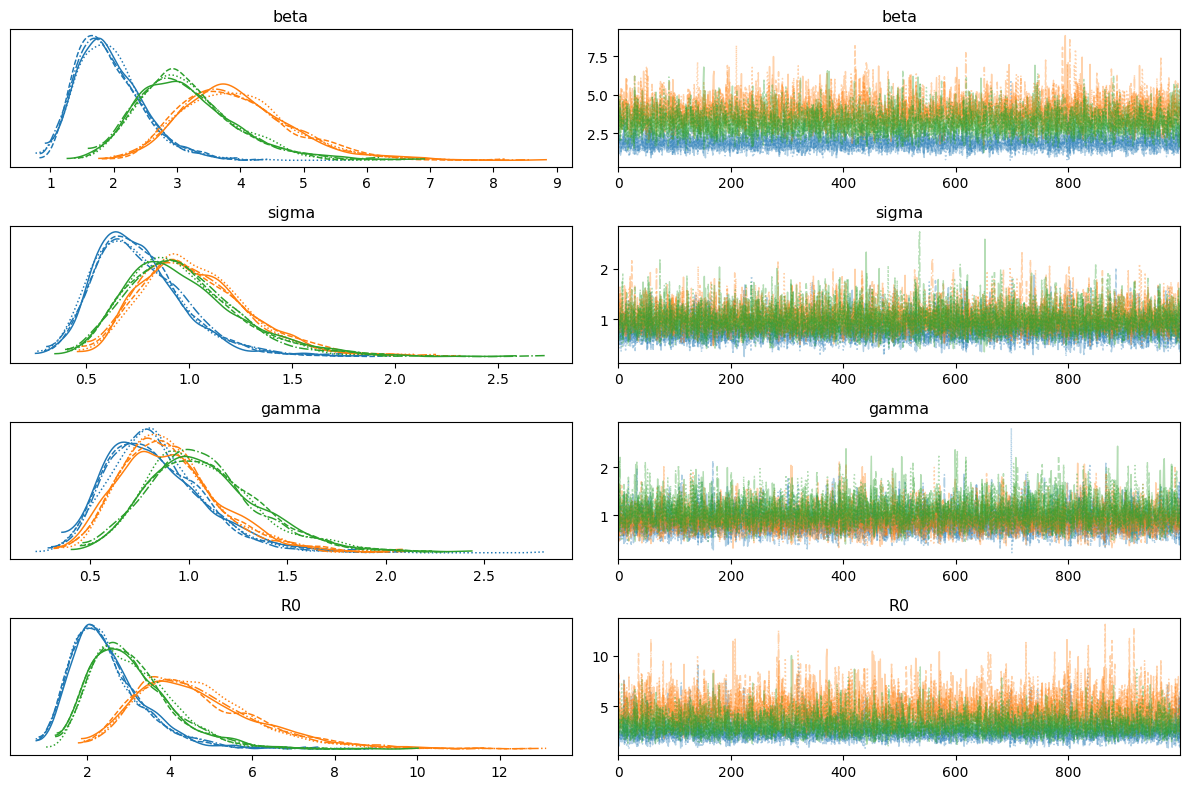

In [68]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)
az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

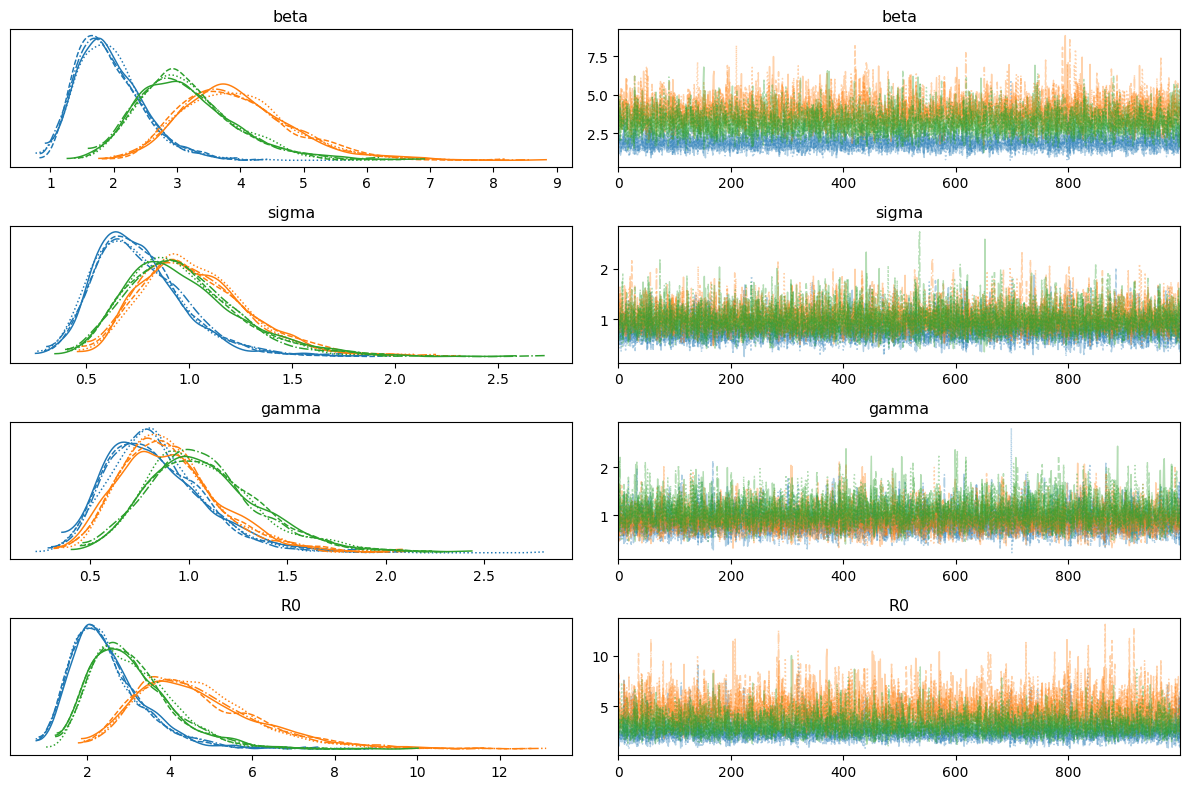

In [69]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [70]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7  # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

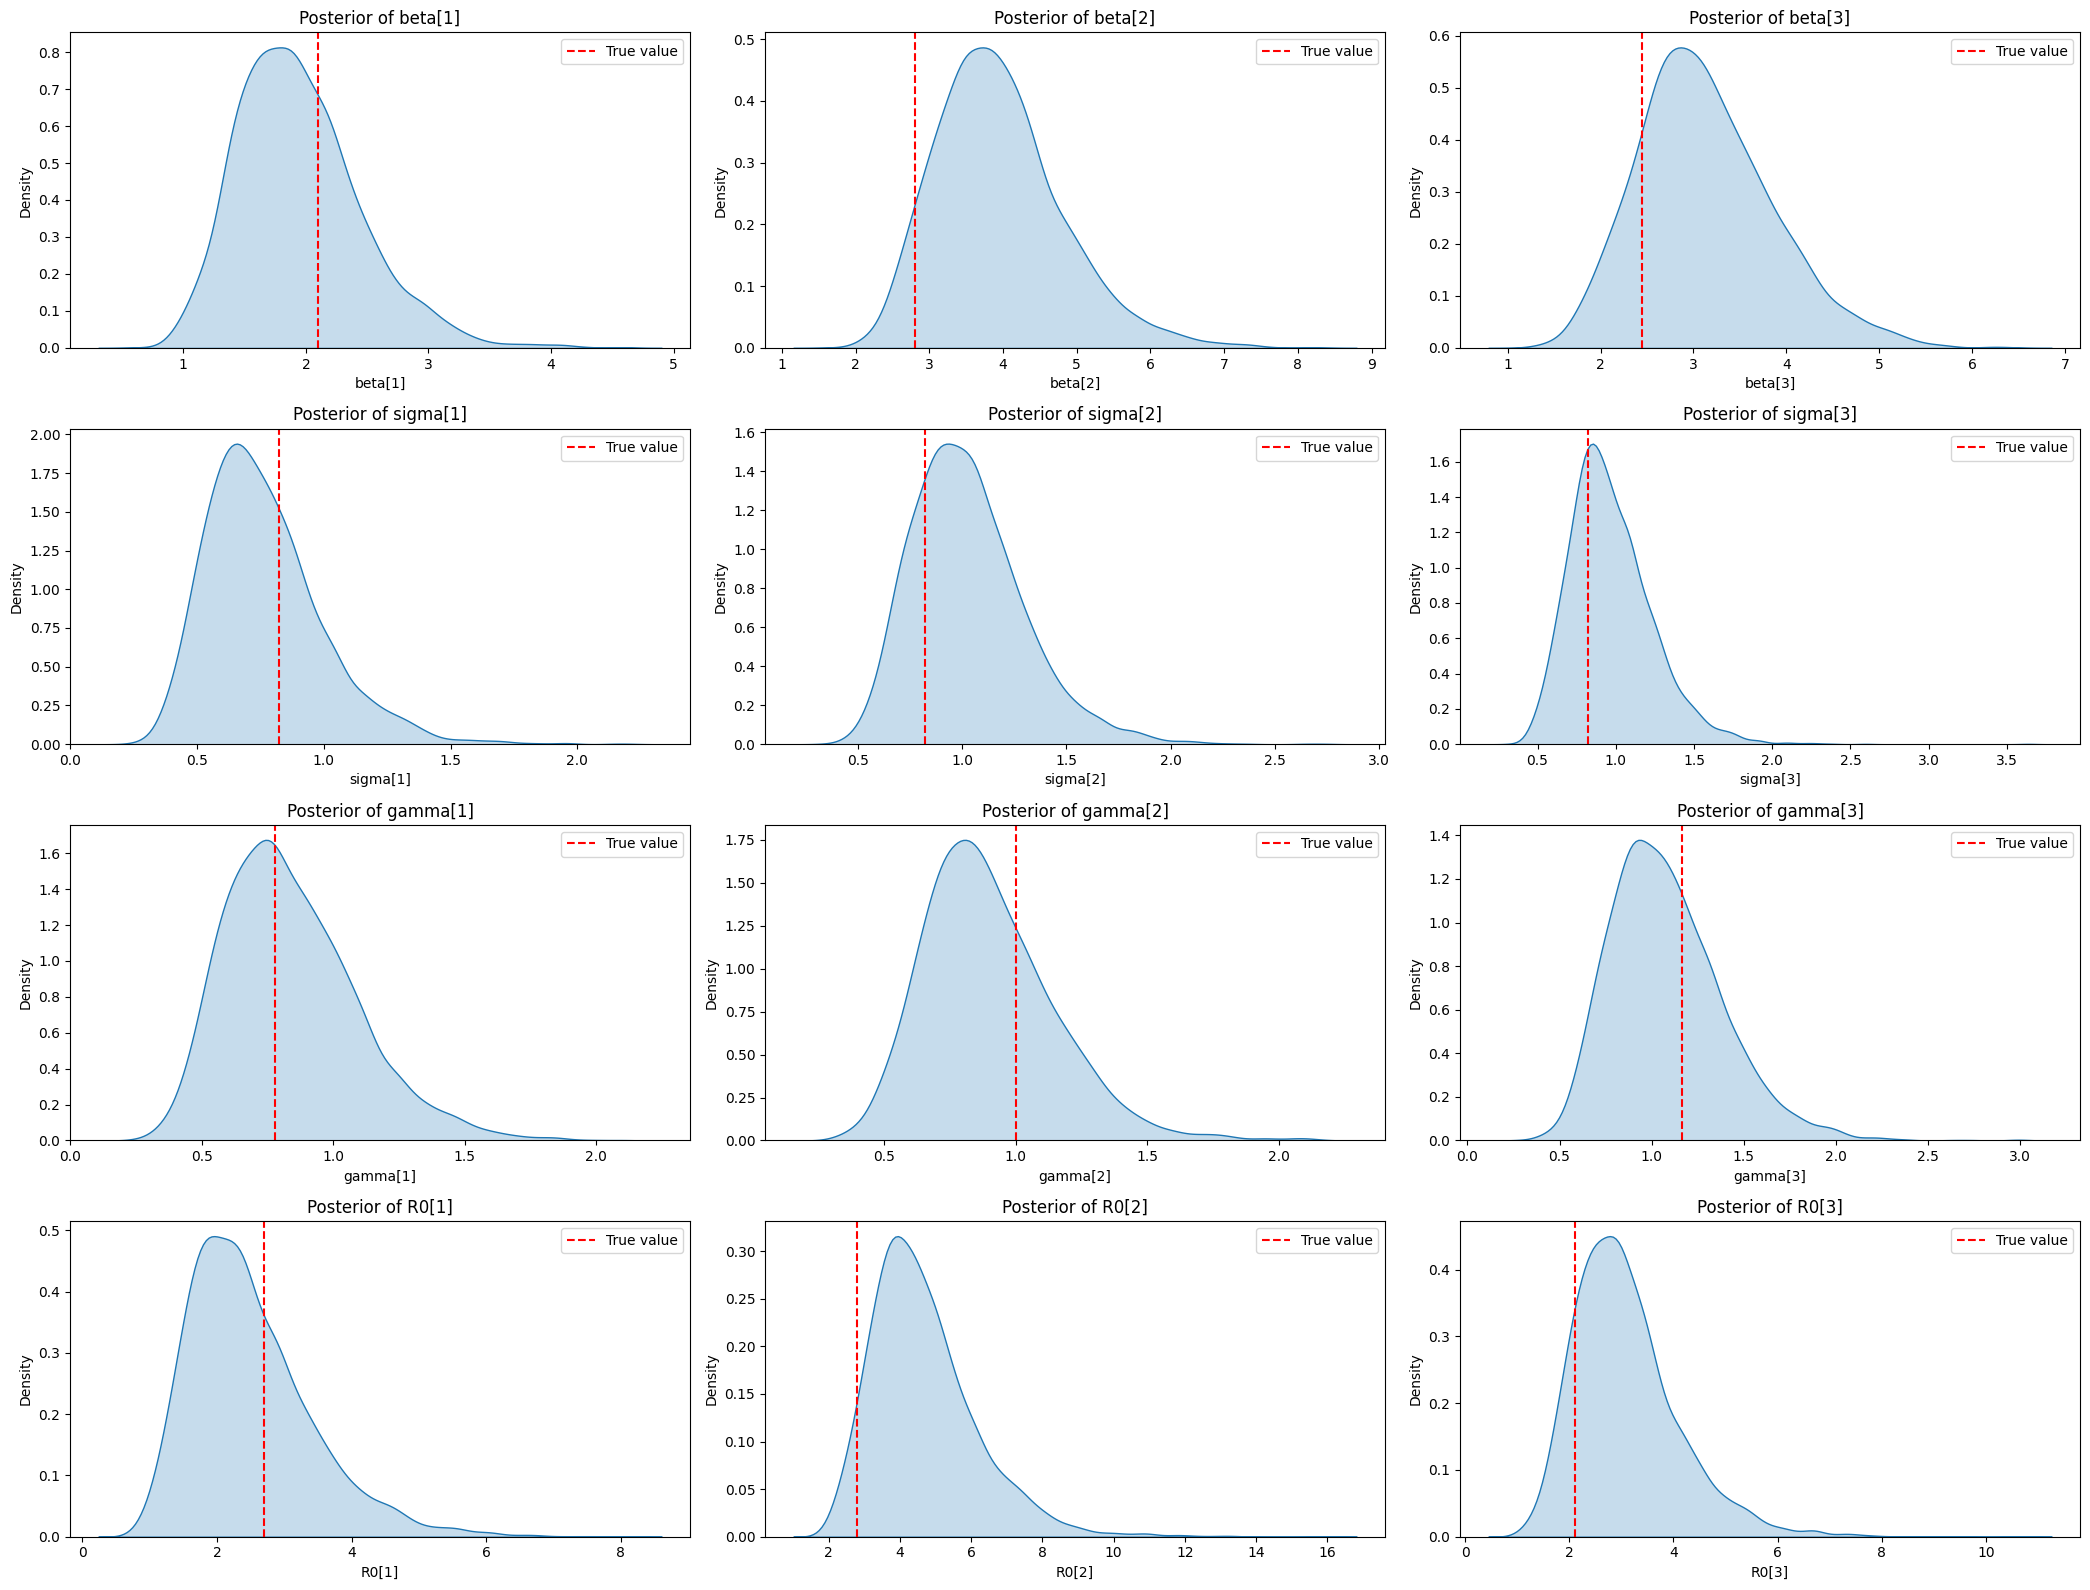

In [383]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
              "sigma[1]","sigma[2]","sigma[3]",
              "gamma[1]","gamma[2]","gamma[3]",
                "R0[1]","R0[2]", "R0[3]"]
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1],'sigma[3]': sigma[2], 
    'gamma[1]': gamma[0],'gamma[2]': gamma[1],'gamma[3]': gamma[2],
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t, save='post_checks_all')

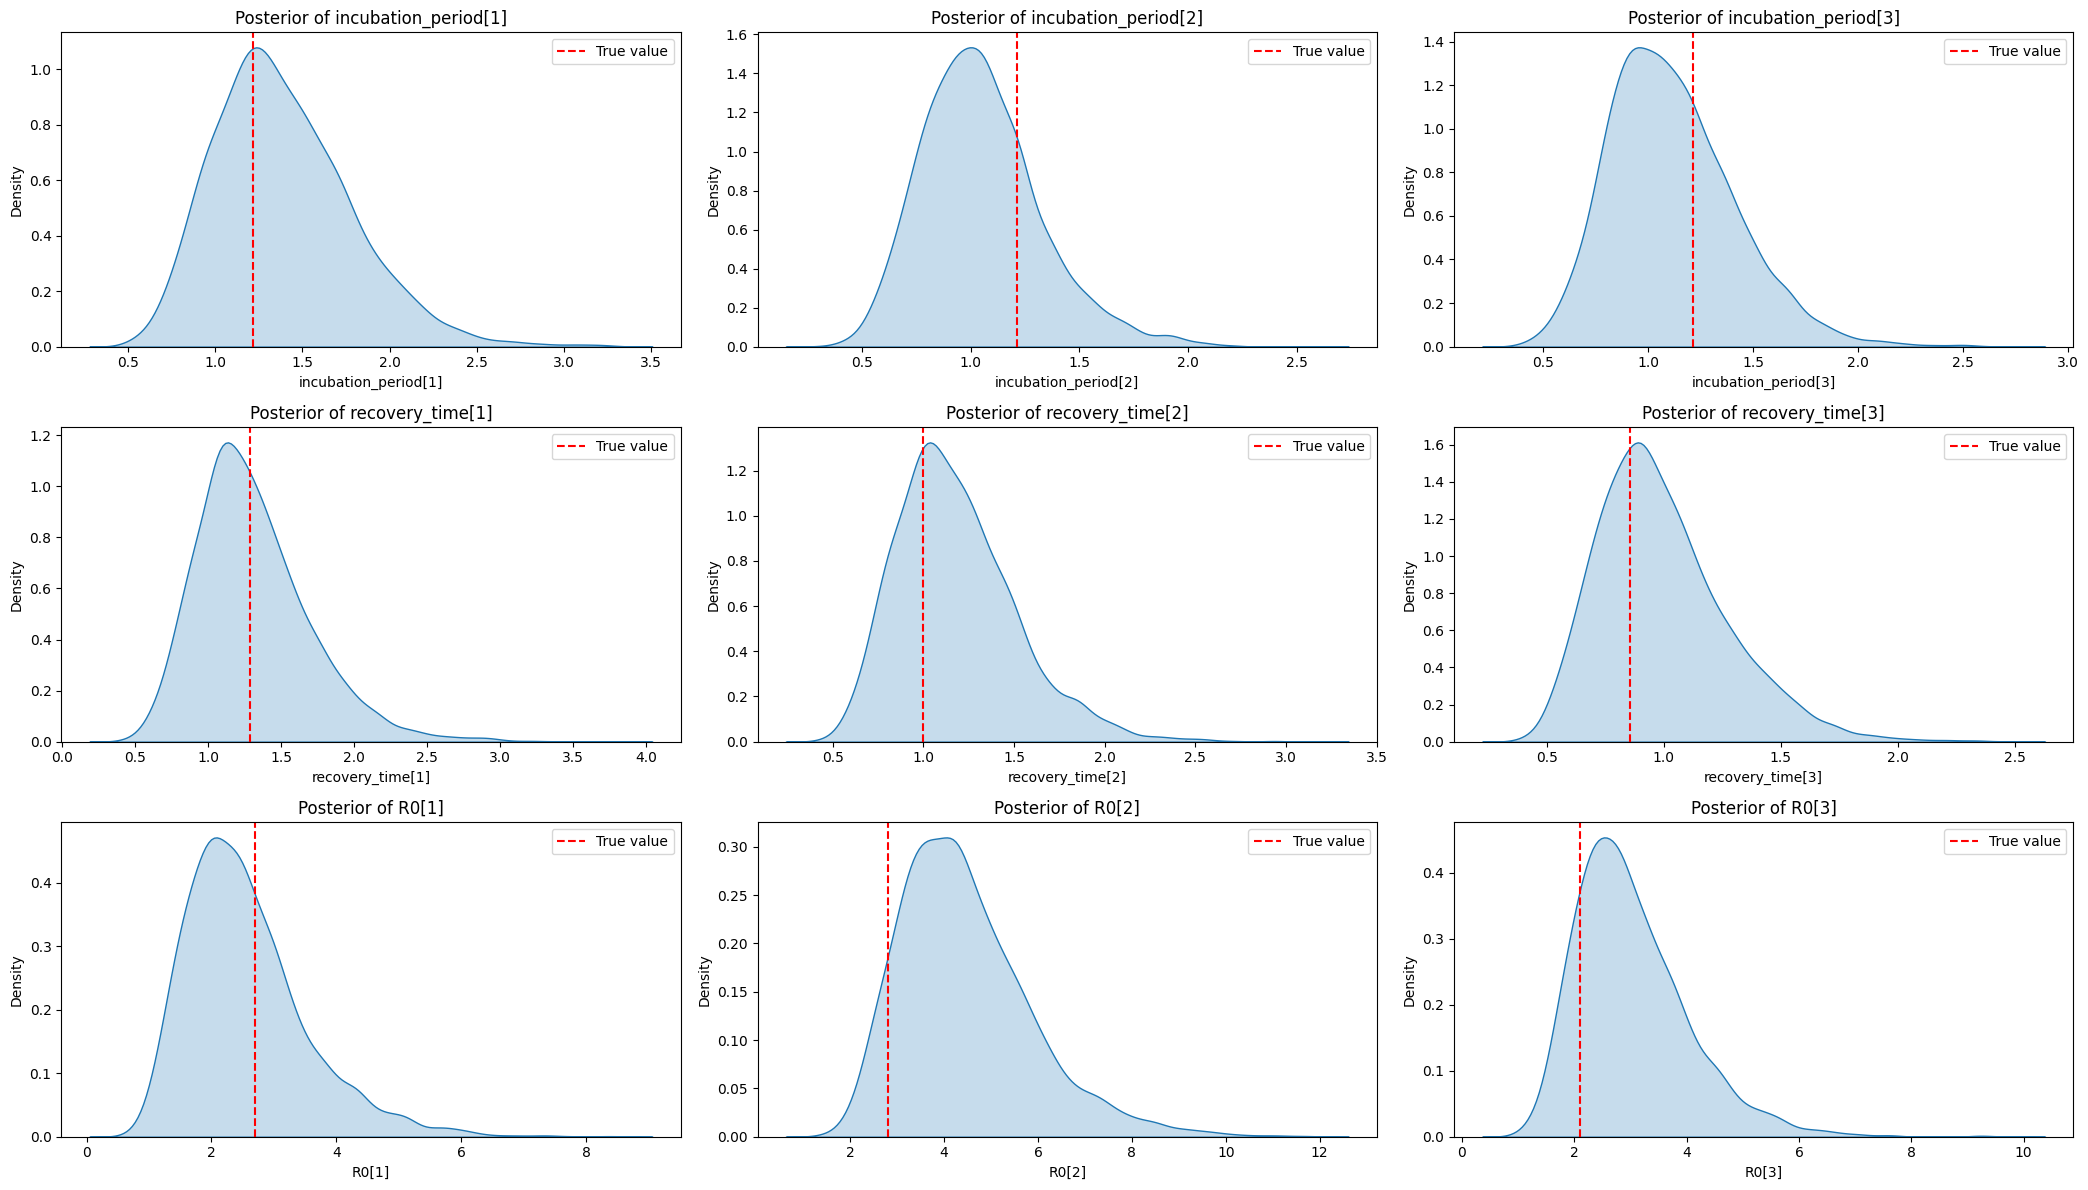

In [61]:
parameters1 = ["incubation_period[1]","incubation_period[2]","incubation_period[3]",
               "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0], 'recovery_time[2]':rec[1], 'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0], 'incubation_period[2]': incu[1], 'incubation_period[3]': incu[2]}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1)

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


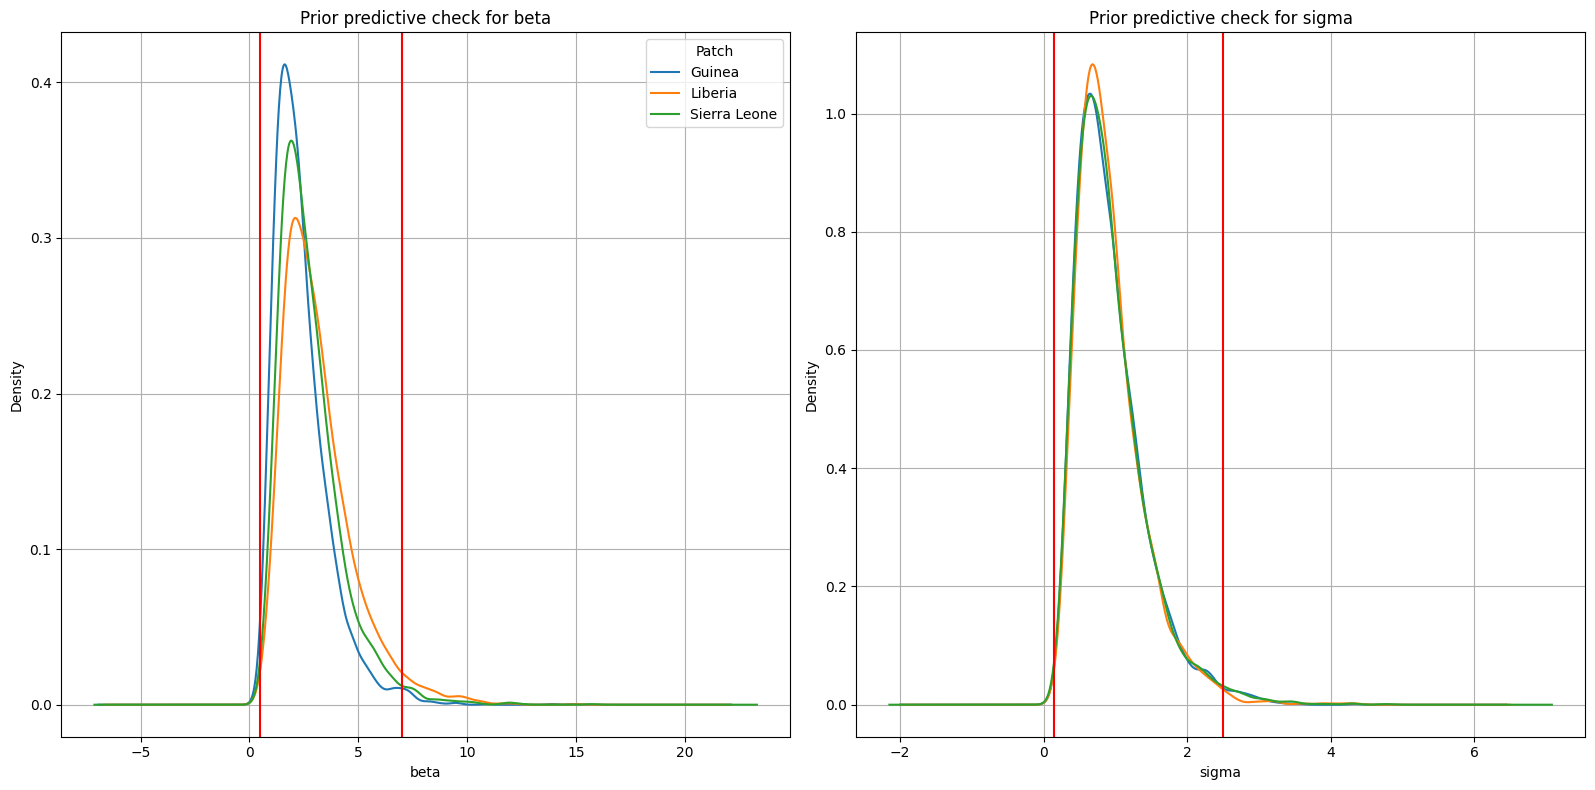

In [ ]:
params = ['beta','sigma', 'gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()